<a href="https://colab.research.google.com/github/asegura4488/MetodosComputacionales2026/blob/main/Semana14/AlgoritmoEvolutivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [78]:
# Vamos a cargar datos
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [79]:
import os
os.chdir("/content/drive/MyDrive/ColabNotebooks/Cursos/MetodosComputacionales2026")

In [80]:
img = Image.open("Semana14/virus.jpg")

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
import copy

In [82]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image

In [83]:
def Plotter(e):

  fig = plt.figure(figsize=(10,3))
  ax = fig.add_subplot(131)
  ax1 = fig.add_subplot(132)
  ax2 = fig.add_subplot(133)
  ax.set_title('Epoch: {:.0f}'.format(e),fontsize=10)

  return ax,ax1,ax2

In [89]:
class Robot:

  def __init__(self, f, rate, Id = 0):
    self.f = f
    self.rate = rate
    self.Id = Id

    # La posicion del bot (gen)
    self.r = np.random.uniform(-5,5.)

    # primera función de fitnes
    self.Fitness = self.f(self.r)

  # Setter de clase
  def SetFitness(self):
    self.Fitness = self.f(self.r)

  # Getters de clase
  def GetR(self):
    return self.r

  def GetFitness(self):
    return self.Fitness

  # Metodos de clase
  def Mutate(self):
    self.r += np.random.normal(loc=0.,scale=self.rate)

In [90]:
f = lambda x: x**2 + 10*np.sin(x)
rate = 0.4

In [91]:
# Necesitamos muchos genes en puntos distintos de la memoria
def GetRobots(N):

  Robots = []


  for i in range(N):
    r = Robot(f,rate,i)
    Robots.append(r)

  return Robots

In [94]:
def Genetic(Robots, epochs=100, Plot=True):


  # Historia de la aptitud
  Vector_Fitness = np.array([])

  # Dominio de la funcion de costo
  t = np.linspace(-5,5,50)

  N = int(0.8*len(Robots)) # Porcentaje de bots a la siguiente generacion

  for e in range(epochs):

    # Limpiamos
    clear_output(wait=True)

    # Zona de mutación y ajuste de fitness
    for i, p in enumerate(Robots):
      p.Mutate()
      p.SetFitness()


    # Zona de Ordenar para seleccion natural
    #score = [(p.GetFitness(),p) for p in Robots]
    #print(score)
    #score = sorted( score, key=lambda x: x[0], reverse=False ) # True para maximizar, False Minimizar
    #print(score)

    #Temp = [r[1] for i, r in enumerate(score) if i < N]

    # Seleccion Natural
    #for i,r in enumerate(Robots):
    #  j = i%N
    #  Robots[i] = copy.deepcopy(Temp[j])


    #Extrameos el fitness
    Fitness = np.array([ p.GetFitness() for i, p in enumerate(Robots) ])
    # Miramos el fitness del ultimo
    Vector_Fitness = np.append(Vector_Fitness, Fitness[0])
    # Posiciones
    Posiciones = [ p.GetR() for i, p in enumerate(Robots)]

    # Condicion para pintar
    if Plot and e%2 == 0:
      ax,ax1,ax2 = Plotter(e)
      ax.plot(t,f(t),color='k')

      # Pintamos los robots
      for i, p in enumerate(Robots):
        ax.scatter(p.GetR(),p.GetFitness(),marker='.')
        #ax.text(p.GetR(),p.GetFitness(),str(p.Id))

        imagebox = OffsetImage(img, zoom=0.02)


        icono = AnnotationBbox(
            imagebox,
            (p.GetR(), p.GetFitness()),
            frameon=False
            )

        ax.add_artist(icono)


      # Pintamos el fitness
      ax1.plot(Vector_Fitness,color='r',label='Fitness {:.3f}'.format(Vector_Fitness[-1]))
      ax1.legend()
      # Pintamos el histograma de posiciones
      ax2.hist(Posiciones,bins=20,density=True,label='Medio {:.3f}'.format(np.mean(Posiciones)))
      ax2.set_xlim(-5,5)
      ax2.legend()

      plt.show()

    time.sleep(0.001)


  return Robots

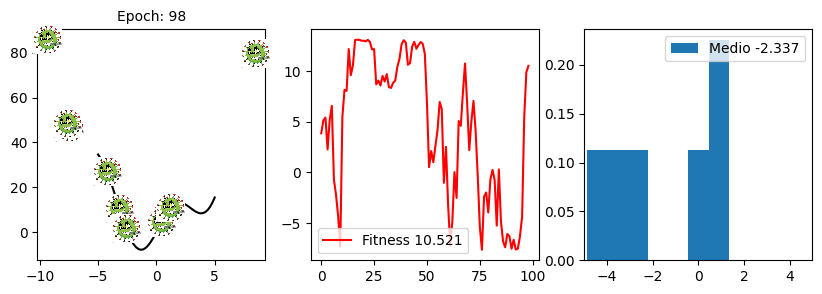

In [95]:
Robots = GetRobots(10)
Robots = Genetic(Robots, Plot=True)

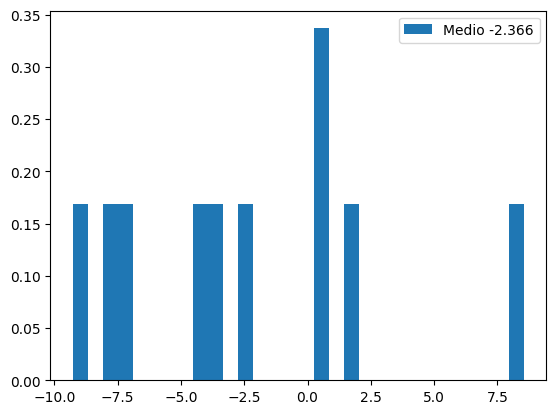

In [96]:
Posiciones = [ p.GetR() for i, p in enumerate(Robots)]
_ = plt.hist(Posiciones,bins=30,density=True,label='Medio {:.3f}'.format(np.mean(Posiciones)))
plt.legend()
plt.show()

In [97]:
f(np.mean(Posiciones))

np.float64(-1.4006107248875468)